#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

#### Load Data

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nChurn distribution:\n", df['Churn'].value_counts(normalize=True))

Shape: (7043, 21)

Dtypes:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0


#### Fix Total Charges Type

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print("Fixed. Null count:", df['TotalCharges'].isnull().sum())

Fixed. Null count: 0


C:\Users\dell\AppData\Local\Temp\ipykernel_28220\3284719783.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


#### Chart-1: Churn Distribution

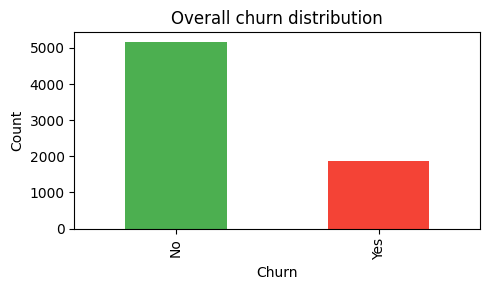

In [4]:
fig, ax = plt.subplots(figsize=(5, 3))
df['Churn'].value_counts().plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'])
ax.set_title('Overall churn distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../data/churn_dist.png', dpi=150)
plt.show()

#### Chart-2: Churn By Contract Type

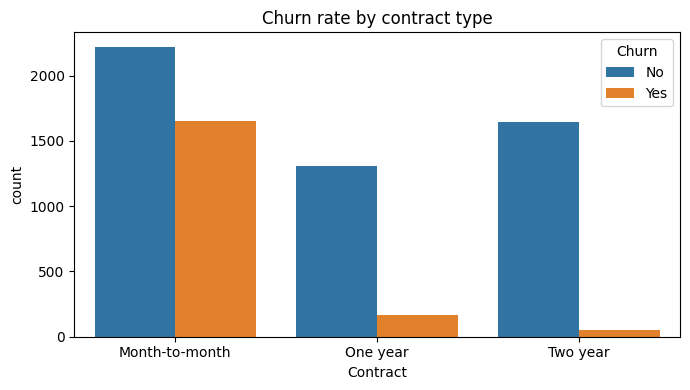

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='Contract', hue='Churn', ax=ax)
ax.set_title('Churn rate by contract type')
plt.tight_layout()
plt.savefig('../data/churn_by_contract.png', dpi=150)
plt.show()

# Print churn % per contract type
print(df.groupby('Contract')['Churn']
        .apply(lambda x: (x=='Yes').mean())
        .mul(100).round(1))

#### Chart-3: Tenure Distribution

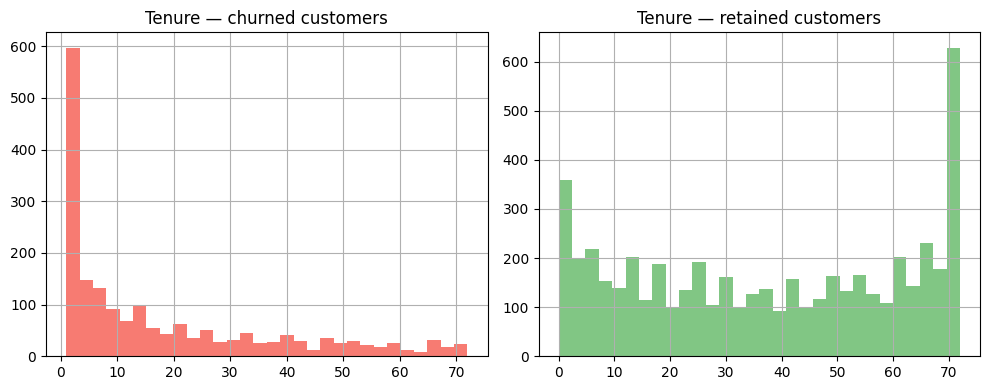

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df[df['Churn']=='Yes']['tenure'].hist(bins=30, ax=axes[0], color='#F44336', alpha=0.7)
axes[0].set_title('Tenure — churned customers')
df[df['Churn']=='No']['tenure'].hist(bins=30, ax=axes[1], color='#4CAF50', alpha=0.7)
axes[1].set_title('Tenure — retained customers')
plt.tight_layout()
plt.show()

#### Chart-4: Monthly Charges Box Plot

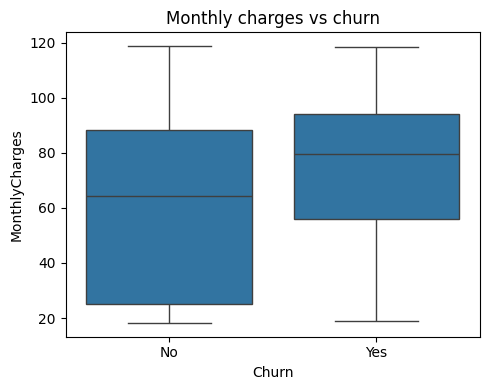

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax)
ax.set_title('Monthly charges vs churn')
plt.tight_layout()
plt.show()

#### Chart-5: Correlation HeatMap

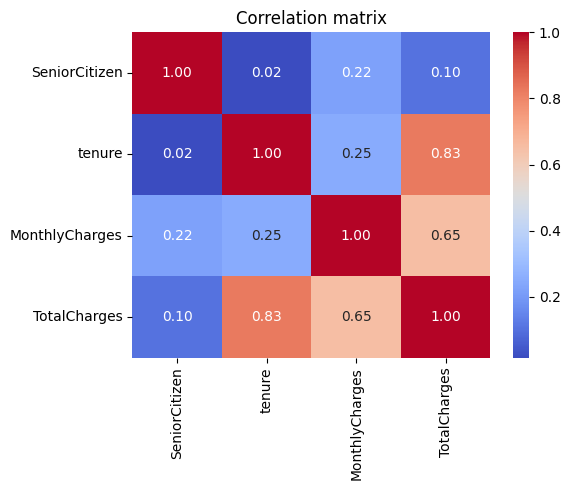

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True, cmap='coolwarm', fmt='.2f', ax=ax
)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()

#### Chart-6: Churn By Internet Service + Tech Support

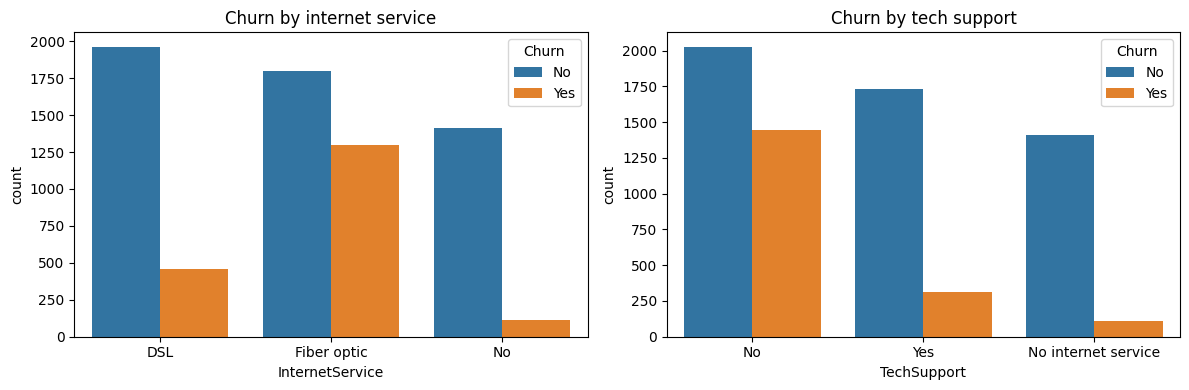

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0])
axes[0].set_title('Churn by internet service')
sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[1])
axes[1].set_title('Churn by tech support')
plt.tight_layout()
plt.show()

#### FINDINGS:
#### 1. Month-to-month contract → 42% churn vs 3% for 2-year contracts
#### 2. Tenure < 12 months → ~50% churn; tenure > 50 months → <5%
#### 3. No TechSupport → 41% churn vs 15% with support
#### 4. Fiber optic internet users churn more (likely due to higher charges)